# Binarization
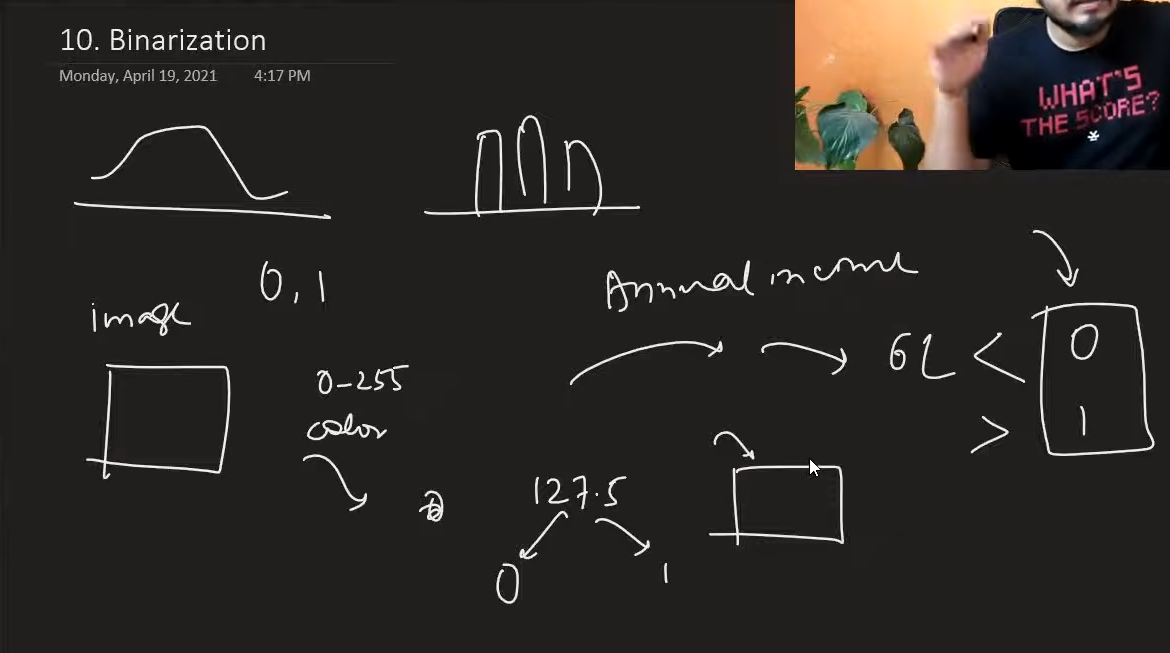

here we convert a numerical value into binary .

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [7]:

df = pd.read_csv('titanic.csv')[['Age','Fare','SibSp','Parch','Survived']]

In [10]:
df.dropna(inplace = True)

In [12]:
df.head()

,Age,Fare,SibSp,Parch,Survived
0,22.0,7.2500,1,0,0
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,1
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,0


In [13]:
df['family'] = df['SibSp']+df['Parch']

In [16]:
df.sample(3)

,Age,Fare,SibSp,Parch,Survived,family
587,60.0,79.2,1,1,1,2
333,16.0,18.0,2,0,0,2
819,10.0,27.9,3,2,0,5


In [17]:
df.drop(columns = ['SibSp','Parch'],inplace = True)

In [18]:
df.head()

,Age,Fare,Survived,family
0,22.0,7.2500,0,1
1,38.0,71.2833,1,1
2,26.0,7.9250,1,0
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [20]:
x = df.drop(columns = ['Survived'])
y = df['Survived']

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [22]:
x_train

,Age,Fare,family
328,31.0,20.5250,2
73,26.0,14.4542,1
253,30.0,16.1000,1
719,33.0,7.7750,0
666,25.0,13.0000,0
...,...,...,...
92,46.0,61.1750,1
134,25.0,13.0000,0
337,41.0,134.5000,0
548,33.0,20.5250,2


In [23]:
# without binarization
clf = DecisionTreeClassifier()
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)
accuracy_score(y_test,y_pred)

0.6363636363636364

In [24]:
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv =10,scoring = 'accuracy'))

np.float64(0.651310641627543)

In [25]:
# Applying binarization
from sklearn.preprocessing import Binarizer

In [26]:
trf = ColumnTransformer([('bin',Binarizer(copy = False),['family'])],remainder = 'passthrough')

In [27]:
x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

In [28]:
pd.DataFrame(x_train_trf,columns = ['family','Age','Fare'])

,family,Age,Fare
0,1.0,31.0,20.5250
1,1.0,26.0,14.4542
2,1.0,30.0,16.1000
3,0.0,33.0,7.7750
4,0.0,25.0,13.0000
...,...,...,...
566,1.0,46.0,61.1750
567,0.0,25.0,13.0000
568,0.0,41.0,134.5000
569,1.0,33.0,20.5250
